In [1]:
import pandas as pd
import numpy as np


In [2]:
df = pd.read_excel('Supply chain logisitcs problem.xlsx')
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 9215 entries, 0 to 9214
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Order ID              9215 non-null   float64       
 1   Order Date            9215 non-null   datetime64[us]
 2   Origin Port           9215 non-null   str           
 3   Carrier               9215 non-null   str           
 4   TPT                   9215 non-null   int64         
 5   Service Level         9215 non-null   str           
 6   Ship ahead day count  9215 non-null   int64         
 7   Ship Late Day count   9215 non-null   int64         
 8   Customer              9215 non-null   str           
 9   Product ID            9215 non-null   int64         
 10  Plant Code            9215 non-null   str           
 11  Destination Port      9215 non-null   str           
 12  Unit quantity         9215 non-null   int64         
 13  Weight                9215 no

,Order ID,Order Date,Origin Port,Carrier,TPT,Service Level,Ship ahead day count,Ship Late Day count,Customer,Product ID,Plant Code,Destination Port,Unit quantity,Weight
0,1.447296e+09,2013-05-26,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,808,14.30
1,1.447158e+09,2013-05-26,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,3188,87.94
2,1.447139e+09,2013-05-26,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,2331,61.20
3,1.447364e+09,2013-05-26,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,847,16.16
4,1.447364e+09,2013-05-26,PORT09,V44_3,1,CRF,3,0,V55555_53,1700106,PLANT16,PORT09,2163,52.34


In [3]:
Target = df['Ship ahead day count'] # The target 
df.drop(columns='Ship ahead day count',inplace=True) 
cat_feat= df.select_dtypes(['object']).columns.to_list() + df.select_dtypes(['datetime64']).columns.to_list()
num_feat = df.select_dtypes(['int']).columns.to_list() + df.select_dtypes(['float']).columns.to_list()
per_cat= (len(cat_feat) / len(df.columns))*100
per_num= len(num_feat) / len(df.columns)*100

display(df.head())
print(f'The percentage of categorical data is {per_cat:.2f}% and numerical features is {per_num:.2f}%')

C:\Users\romma\AppData\Local\Temp\ipykernel_27660\633550255.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_feat= df.select_dtypes(['object']).columns.to_list() + df.select_dtypes(['datetime64']).columns.to_list()


,Order ID,Order Date,Origin Port,Carrier,TPT,Service Level,Ship Late Day count,Customer,Product ID,Plant Code,Destination Port,Unit quantity,Weight
0,1.447296e+09,2013-05-26,PORT09,V44_3,1,CRF,0,V55555_53,1700106,PLANT16,PORT09,808,14.30
1,1.447158e+09,2013-05-26,PORT09,V44_3,1,CRF,0,V55555_53,1700106,PLANT16,PORT09,3188,87.94
2,1.447139e+09,2013-05-26,PORT09,V44_3,1,CRF,0,V55555_53,1700106,PLANT16,PORT09,2331,61.20
3,1.447364e+09,2013-05-26,PORT09,V44_3,1,CRF,0,V55555_53,1700106,PLANT16,PORT09,847,16.16
4,1.447364e+09,2013-05-26,PORT09,V44_3,1,CRF,0,V55555_53,1700106,PLANT16,PORT09,2163,52.34


The percentage of categorical data is 53.85% and numerical features is 46.15%


In [4]:
for c in cat_feat:
 unique = df[c].unique()
 print(f'The feature {c} has {len(unique)} types')
for c in num_feat:
 unique = df[c].unique()
 max = unique.max()
 min = unique.min()
 range = (max - min)
 print(f'The feature {c} has {len(unique)} types and of range {range} between {min} and {max}')

The feature Origin Port has 3 types
The feature Carrier has 3 types
The feature Service Level has 3 types
The feature Customer has 46 types
The feature Plant Code has 7 types
The feature Destination Port has 1 types
The feature Order Date has 1 types
The feature TPT has 5 types and of range 4 between 0 and 4
The feature Ship Late Day count has 4 types and of range 6 between 0 and 6
The feature Product ID has 772 types and of range 89333 between 1613321 and 1702654
The feature Unit quantity has 2624 types and of range 561612 between 235 and 561847
The feature Order ID has 9215 types and of range 299425.0 between 1447125805.7 and 1447425230.7
The feature Weight has 5899 types and of range 2338.4051259623893 between 0.0 and 2338.4051259623893


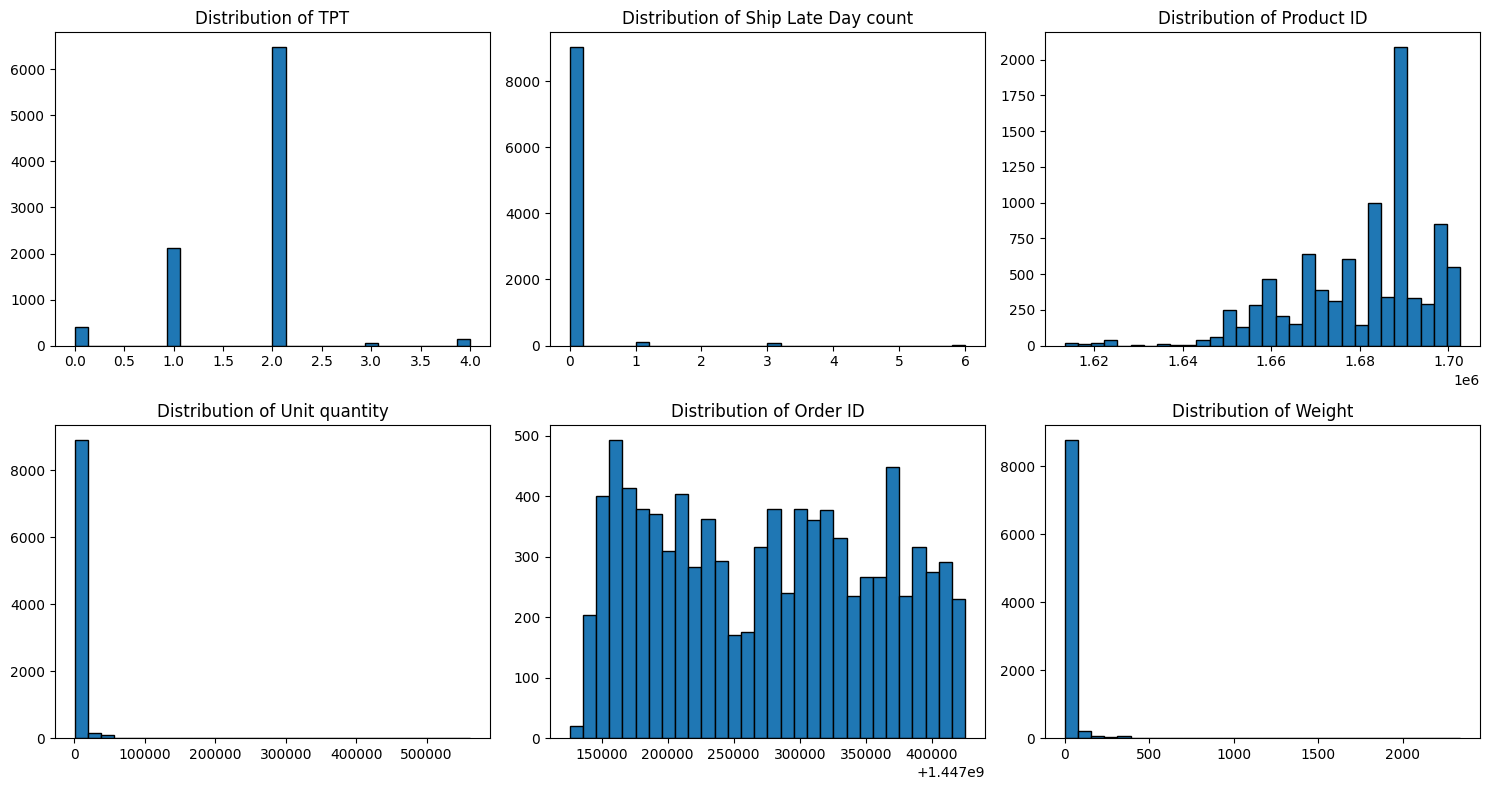

In [7]:
import matplotlib.pyplot as plt

import math

# Calculate rows needed based on 3 columns
num_plots = len(num_feat)
rows = math.ceil(num_plots / 3) 

fig, axis = plt.subplots(rows, 3, figsize=(15, rows * 4))
axis = axis.flatten() # Flatten makes it much easier to loop

for i, c in enumerate(num_feat):
    axis[i].hist(df[c],bins=30, edgecolor='black')
    axis[i].set_title(f'Distribution of {c}')

plt.tight_layout()

In [8]:
# Drop IDs first (logically has no infulence)
df.drop(columns=['Order ID', 'Product ID'], inplace=True)

# Identify columns with zero variance (only 1 unique value) and drop them
dropped_feat = ['Order ID', 'Product ID']
for c in df.columns:
    if df[c].nunique() <= 1: 
        df.drop(columns=c, inplace=True)
        dropped_feat.append(c)

# Removes anything in dropped_feat from num_feat
num_feat = [f for f in num_feat if f not in dropped_feat]
cat_feat = [f for f in cat_feat if f not in dropped_feat]

# Apply qcut to numeric features with many unique values
for c in num_feat:
    if df[c].nunique() > 6:
        df[c] = pd.qcut(df[c], q=6, labels=[1, 2, 3, 4, 5, 6])

#  One-Hot Encoding 
df = pd.get_dummies(df, columns=cat_feat, drop_first=True)

df.tail()

,TPT,Ship Late Day count,Unit quantity,Weight,Origin Port_PORT05,Origin Port_PORT09,Carrier_V444_1,Carrier_V44_3,Service Level_DTD,Service Level_DTP,...,Customer_V55_13,Customer_V55_37,Customer_V55_39,Customer_V55_47,Plant Code_PLANT04,Plant Code_PLANT08,Plant Code_PLANT09,Plant Code_PLANT12,Plant Code_PLANT13,Plant Code_PLANT16
9210,1,0,2,3,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9211,1,0,2,3,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9212,1,0,1,1,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9213,1,0,1,3,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False
9214,1,0,2,2,False,False,True,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split the data
X_train, X_test, y_train, y_test = train_test_split(df , Target, test_size=0.2, random_state=42)

# Define the model
model = LogisticRegression(max_iter=1000)

# 3. Train
model.fit(X_train, y_train)

# 4. Predict
y_pred = model.predict(X_test)

--- Performance Metrics ---
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       847
           1       1.00      1.00      1.00        17
           3       0.98      0.94      0.96       678
           5       0.93      1.00      0.96       300
           6       1.00      1.00      1.00         1

    accuracy                           0.96      1843
   macro avg       0.97      0.98      0.98      1843
weighted avg       0.96      0.96      0.96      1843

Accuracy: 0.96


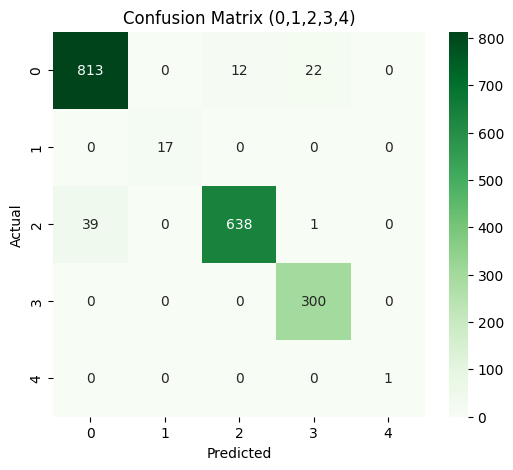

In [21]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# Display the raw Classification Report
print("--- Performance Metrics ---")
report = classification_report(y_test, y_pred)
print(report)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
# Create the Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix (0,1,2,3,4)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()